# Домашнее задание к занятию «Деревья решений»

Выполнил: Ярослав Золотухин

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
housing = fetch_california_housing(as_frame=True)
housing.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


Пропуски отсутствуют.

In [3]:
housing.data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


### Нормализуем столбец Population (из-за большого масштаба и разброса в сравнении с другими признаками)

In [4]:
scaler = StandardScaler()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target

df['Population'] = scaler.fit_transform(df[['Population']])

print(df['Population'].head())

0   -0.974429
1    0.861439
2   -0.820777
3   -0.766028
4   -0.759847
Name: Population, dtype: float64


### Строим линейную модель регрессии

In [5]:
X = df.drop(columns=['Target'])
Y = df['Target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
model_linear = LinearRegression()
model_linear.fit( X_train, y_train )
score = model_linear.score(X_test, y_test)
print(score)

0.5757877060324511


Качество получилось посредственным. Попробуем обучить модель используя деревья решений.

### Строим дерево решений

In [8]:
from sklearn.tree import DecisionTreeRegressor

X_2 = housing.data
Y_2 = housing.target

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, Y_2, test_size=0.2, random_state=42)

model_tree = DecisionTreeRegressor(random_state=10).fit(X_train_2, y_train_2)

score_tree = model_tree.score(X_test_2, y_test_2)
print(f"Score: {score_tree}")

Score: 0.6235980781798847


### Визуализируем дерево

При визуализации дерева для получения читаемого вида установлено ограничение глубины

[Text(0.5, 0.9, 'x[0] <= 5.086\nsquared_error = 1.337\nsamples = 16512\nvalue = 2.072'),
 Text(0.25, 0.7, 'x[0] <= 3.074\nsquared_error = 0.834\nsamples = 13101\nvalue = 1.74'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[2] <= 4.314\nsquared_error = 0.561\nsamples = 6268\nvalue = 1.358'),
 Text(0.0625, 0.3, 'x[0] <= 2.215\nsquared_error = 0.679\nsamples = 2624\nvalue = 1.626'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'x[0] <= 2.418\nsquared_error = 0.387\nsamples = 3644\nvalue = 1.165'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'x[5] <= 2.418\nsquared_error = 0.827\nsamples = 6833\nvalue = 2.09'),
 Text(0.3125, 0.3, 'x[6] <= 37.935\nsquared_error = 1.248\nsamples = 1755\nvalue = 2.736'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 'x[0] <= 4.121\nsquared_error = 0.488\nsamples = 5078\nvalue = 1.867'),
 Text(0.40625, 0.1, '

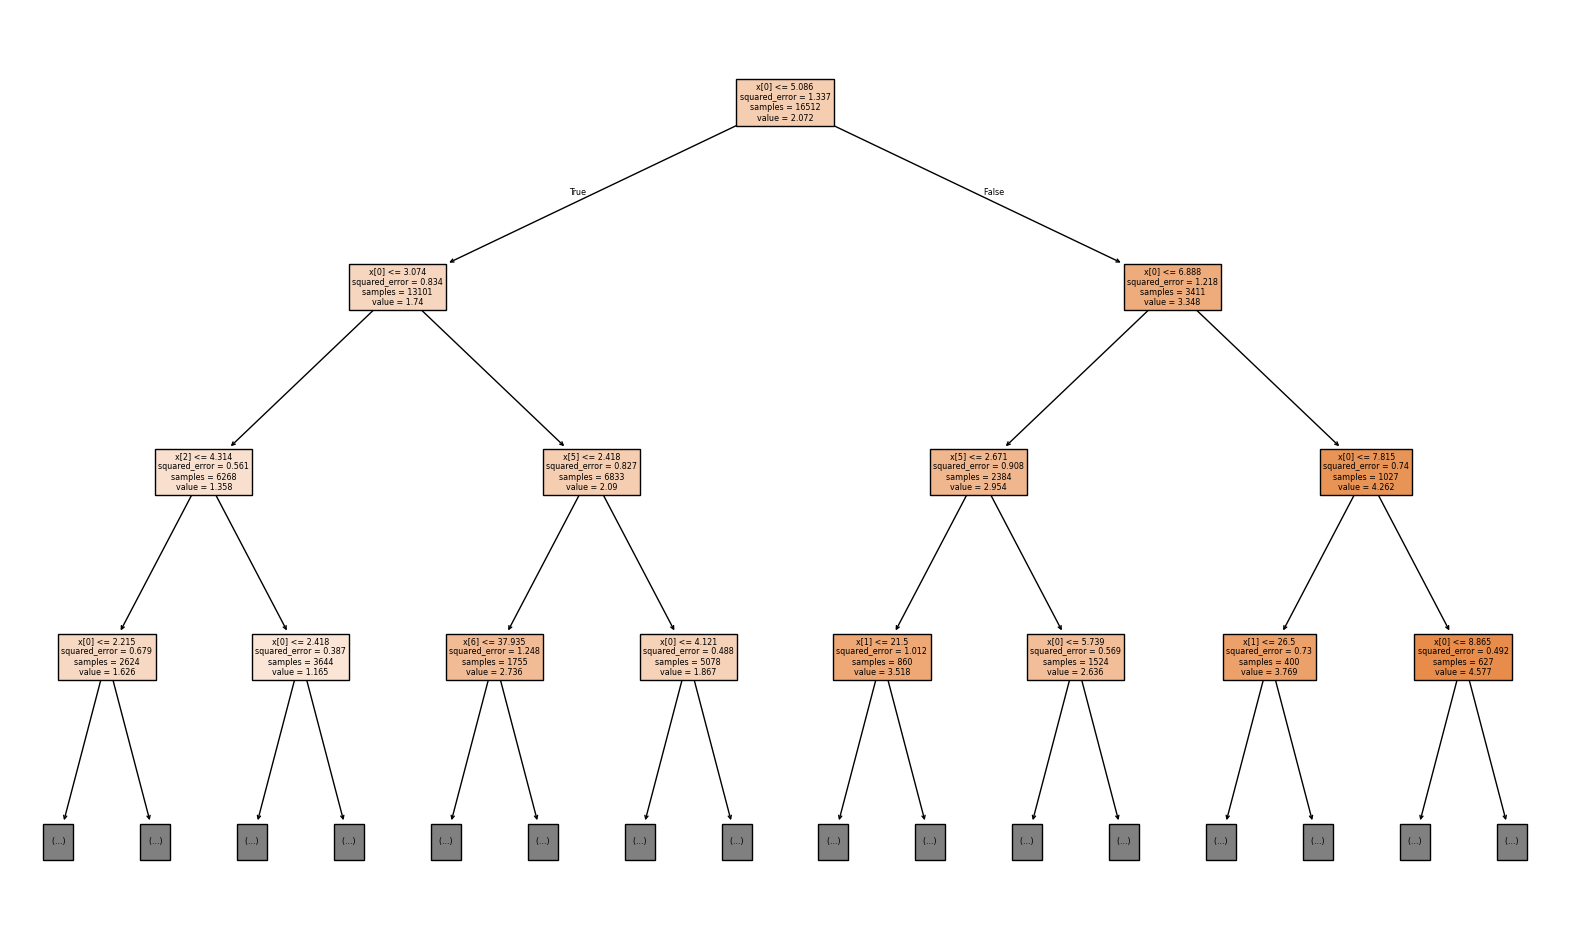

In [9]:
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt

plt.figure(figsize=(20, 12))
plot_tree(model_tree, max_depth=3, filled=True)

### Подбор оптимальных параметров max_depth и min_samples_leaf для модели

Для оптимизации используется встроенная функция в sklearn - RandomizedSearchCV

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 20),
    'min_samples_leaf': randint(1, 20)
}

random_search = RandomizedSearchCV(
    model_tree, param_distributions=param_dist,
    n_iter=100, cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1, random_state=42
)
random_search.fit(X_train_2, y_train_2)

print("Лучшие параметры:", random_search.best_params_)

Лучшие параметры: {'max_depth': 13, 'min_samples_leaf': 16}


In [11]:
score_tree_optimized = random_search.score(X_test_2, y_test_2)
print(f"Score: {score_tree}")

Score: 0.6235980781798847


# Выводы по проделанной работе

В ходе данного домашнего задания был выполнен анализ датасета с данными о недвижимости Калифорнии.

После подготовки данных рассматривались 3 модели, которые показали следующую точность:

| Модель | Точность  |
|--------|----------------------|
| LinearRegression | 0.5757 | 
| DecisionTreeRegressor | 0.6235 |
| DecisionTreeRegressor с оптимизацией | 0.6235 |

Модели с деревьями решений справились лучше, чем линейная регрессия, но точность все равно низкая. Оптимизация не дала необходимого повышения качества модели. 

Линейная модель необходимо использовать при небольшой выборке данных, линейной зависимости между данными, и когда необходима экстраполяция.

Деревья решений необходимо использовать при нелинейных зависимостях и необходимости учета пропусков.